# Анализ сотрудников WrapItUp

необходимо определить, какие сотрудники нужны сервису WrapItUp на старте, оценить рыночные зарплаты по похожим вакансиям и рассчитать примерную стоимость команды для компании.

В анализ включены три ключевые роли:

1. Упаковщик подарков

2. Менеджер заказов

3. Курьер


## Источники данных

Для анализа используются данные из нескольких открытых источников:

1. hh.ru — парсинг резюме по позициям "упаковщик", "менеджер заказов", "курьер".

2. SuperJob — парсинг резюме, дополнительная проверка зарплат.

3. Avito Работа — вакансии, собранные вручную, пример ожидаемых условий.


In [1]:
import pandas as pd

import requests

import matplotlib.pyplot as plt

import numpy as np

In [2]:
import requests

from bs4 import BeautifulSoup

def check_url_for_parsing(url):

    headers = {

        "User-Agent": "Mozilla/5.0"

    }

    try:

        response = requests.get(url, headers=headers, timeout=10)

        print("URL:", url)

        print("Status code:", response.status_code)

        print("Content type:", response.headers.get("Content-Type"))

        print("HTML length:", len(response.text))

        if response.status_code != 200:

            print(" Страница недоступна для обычного requests")

            return

        soup = BeautifulSoup(response.text, "html.parser")

        title = soup.title.text.strip() if soup.title else "Нет title"

        print("Title:", title)

        text = soup.get_text(" ", strip=True).lower()

        keywords = ["вакансия", "зарплата", "курьер", "упаковщик", "менеджер", "руб", "₽"]

        print("\nНайденные ключевые слова:")

        for word in keywords:

            print(word, "→", word in text)

        print("\nПервые 1000 символов текста:")

        print(text[:1000])

    except Exception as e:

        print("Ошибка:", e)

In [3]:
urls = [

    "https://hh.ru/search/resume?text=%D0%A3%D0%BF%D0%B0%D0%BA%D0%BE%D0%B2%D1%89%D0%B8%D0%BA&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0",

    "https://profi.ru/artist/upakovka-podarkov/?seamless=1&tabName=PROFILES&searchTerm=%D0%A3%D0%BF%D0%B0%D0%BA%D0%BE%D0%B2%D0%BA%D0%B0+%D0%BF%D0%BE%D0%B4%D0%B0%D1%80%D0%BA%D0%BE%D0%B2&fromSection=page_main_search$0",

    "https://www.avito.ru/moskva/rezume?cd=1&context=H4sIAAAAAAAA_wEmANn_YToxOntzOjE6InkiO3M6MTY6IjRPSWxkTEViZUwwam5nTVYiO31NXNbVJgAAAA&localPriority=0&q=%D1%83%D0%BF%D0%B0%D0%BA%D0%BE%D0%B2%D1%89%D0%B8%D1%86%D0%B0$0"

]

for url in urls:

    print("=" * 80)

    check_url_for_parsing(url)

URL: https://hh.ru/search/resume?text=%D0%A3%D0%BF%D0%B0%D0%BA%D0%BE%D0%B2%D1%89%D0%B8%D0%BA&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0
Status code: 200
Content type: text/html; charset=utf-8
HTML length: 859265
Title: Поиск сотрудников по резюме в Москве на hh.ru — сайт для подбора кандидатов

Найденные ключевые слова:
вакансия → True
зарплата → False
курьер → False
упаковщик → True
менеджер → True
руб → False
₽ → True

Первые 1000 символов текста:
поиск сотрудников по резюме в москве на hh.ru — сайт для подбора кандидатов произошла ошибка. попробуйте перезагрузить страницу. мы используем файлы cookie, чтобы обеспечивать правильную работу нашего веб-сайта и анализировать сетевой трафик. правила использования файлов cookie мы используем файлы cookie. правила использования файлов cookie понятно для работы с на

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
from urllib.parse import quote

In [5]:
urls = {
    "упаковщик": "https://hh.ru/search/resume?text=%D0%A3%D0%BF%D0%B0%D0%BA%D0%BE%D0%B2%D1%89%D0%B8%D0%BA&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0",
    "менеджер заказов": "https://hh.ru/search/resume?text=%D0%BC%D0%B5%D0%BD%D0%B5%D0%B4%D0%B6%D0%B5%D1%80+%D0%B7%D0%B0%D0%BA%D0%B0%D0%B7%D0%BE%D0%B2&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0",
    "курьер": "https://hh.ru/search/resume?text=%D0%BA%D1%83%D1%80%D1%8C%D0%B5%D1%80&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0"
}

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

def clean_salary(salary_text):
    salary_text = (
        salary_text
        .replace(" ", "")
        .replace("\u202f", "")
        .replace("\u2009", "")
        .replace("₽", "")
    )
    return int(salary_text)

def extract_all_salaries(text):
    pattern = r'\d[\d\s\u202f\u2009]{2,}\s*₽'
    salaries_raw = re.findall(pattern, text)

    salaries = []

    for salary in salaries_raw:
        try:
            salaries.append(clean_salary(salary))
        except:
            pass

    return salaries

def parse_salary_from_search_page(position, url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)

    print(position, response.status_code)

    if response.status_code != 200:
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True)

    salaries = extract_all_salaries(text)

    result = []

    for salary in salaries:
        if 20000 <= salary <= 300000:
            result.append({
                "source": "hh.ru resumes",
                "position": position,
                "salary_expected": salary,
                "url": url
            })

    return result

In [7]:
all_data = []

for position, url in urls.items():
    all_data.extend(parse_salary_from_search_page(position, url))

df = pd.DataFrame(all_data)

df.head()

упаковщик 200
менеджер заказов 200
курьер 200


,source,position,salary_expected,url
0,hh.ru resumes,упаковщик,60000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
1,hh.ru resumes,упаковщик,80000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
2,hh.ru resumes,упаковщик,90000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
3,hh.ru resumes,упаковщик,80000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
4,hh.ru resumes,упаковщик,90000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...


In [8]:
df.shape

(35, 4)

In [9]:
df = df.drop_duplicates()

df.shape

(21, 4)

In [10]:
df.groupby("position")["salary_expected"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
position,,,,,,,,
курьер,7.0,54285.714,22253.946,25000.0,40000.0,50000.0,70000.0,85000.0
менеджер заказов,9.0,96666.667,48153.401,45000.0,60000.0,90000.0,120000.0,200000.0
упаковщик,5.0,73000.000,12041.595,60000.0,65000.0,70000.0,80000.0,90000.0


In [11]:
df

,source,position,salary_expected,url
0,hh.ru resumes,упаковщик,60000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
1,hh.ru resumes,упаковщик,80000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
2,hh.ru resumes,упаковщик,90000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
5,hh.ru resumes,упаковщик,70000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
6,hh.ru resumes,упаковщик,65000,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
11,hh.ru resumes,менеджер заказов,60000,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
12,hh.ru resumes,менеджер заказов,120000,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
14,hh.ru resumes,менеджер заказов,200000,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
15,hh.ru resumes,менеджер заказов,50000,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
16,hh.ru resumes,менеджер заказов,90000,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...


In [12]:
df.to_csv("hh_resumes_parsed.csv", index=False)

In [13]:
salary_stats = (
    df.groupby("position")["salary_expected"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

salary_stats = salary_stats.round(3)
salary_stats

,position,count,mean,median,min,max
0,курьер,7,54285.714,50000.0,25000,85000
1,менеджер заказов,9,96666.667,90000.0,45000,200000
2,упаковщик,5,73000.000,70000.0,60000,90000


In [14]:
salary_stats["total_cost_mean"] = salary_stats["mean"] * 1.30
salary_stats["total_cost_median"] = salary_stats["median"] * 1.30

salary_stats = salary_stats.round(3)
salary_stats

,position,count,mean,median,min,max,total_cost_mean,total_cost_median
0,курьер,7,54285.714,50000.0,25000,85000,70571.428,65000.0
1,менеджер заказов,9,96666.667,90000.0,45000,200000,125666.667,117000.0
2,упаковщик,5,73000.000,70000.0,60000,90000,94900.000,91000.0


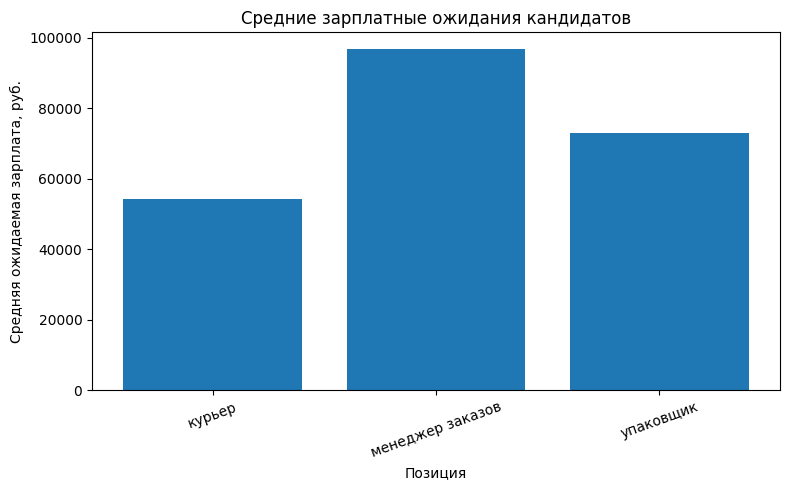

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(salary_stats["position"], salary_stats["mean"])
plt.title("Средние зарплатные ожидания кандидатов")
plt.xlabel("Позиция")
plt.ylabel("Средняя ожидаемая зарплата, руб.")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

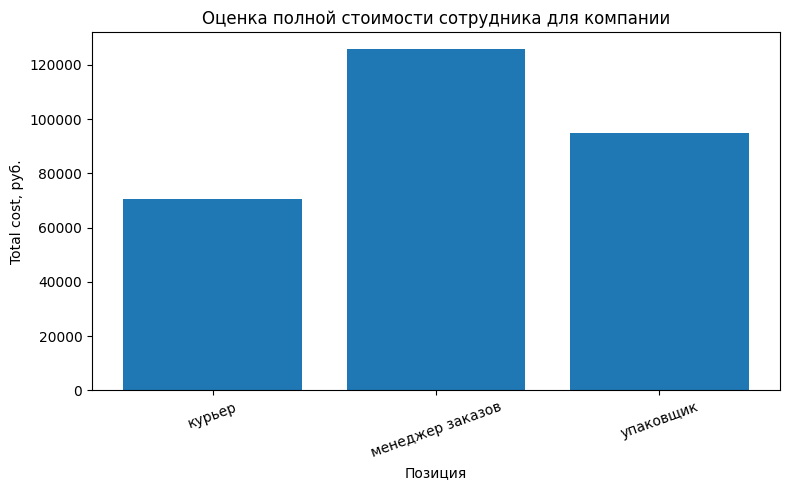

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(salary_stats["position"], salary_stats["total_cost_mean"])
plt.title("Оценка полной стоимости сотрудника для компании")
plt.xlabel("Позиция")
plt.ylabel("Total cost, руб.")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Мучительный парсинг SuperJob и РаботаРу разными способами не увенчался успехом, поэтому сразу перейдем к ручному перебору вакансий на Авито
К этому вернемся потом (наверное)

Попытка автоматического парсинга Avito показала ограничение доступа: сайт возвращал статус 429. Поэтому Avito используется как дополнительный источник, данные из которого были собраны вручную с сохранением ссылок на объявления.


In [17]:
import pandas as pd
import numpy as np

WORKING_DAYS = 22
WORKING_HOURS = 176

avito_jobs = pd.DataFrame([
    [1, "упаковщик", "цветочная компания", "Сборщик / упаковщик / комплектовщик", 110000, np.nan, np.nan, 110000, "месячная", "5/2", "высокая", "сборка и упаковка заказов, работа с цветами и декором", "https://www.avito.ru/moskva/vakansii/sborschikupakovschikkomplektovschik_8089570320"],
    [2, "упаковщик", "склад лёгкой продукции", "Комплектовщик / упаковщик", 72000, np.nan, np.nan, 72000, "месячная", "2/2", "средняя", "упаковка и комплектация, но без подарочной специфики", "https://www.avito.ru/moskva/vakansii/komplektovschik_upakovschik_8016132489"],
    [3, "упаковщик", "сервисная комплектация", "Комплектовщик белья", 48512.5, np.nan, np.nan, 48512.5, "месячная", "не указано", "низкая", "комплектация и упаковка есть, но сфера далека от подарочного сервиса", "https://www.avito.ru/moskva_zelenograd/vakansii/komplektovschik_upakovschik_belya_2631975144"],
    [4, "упаковщик", "интернет-заказы", "Сборщик заказов, сменный график", np.nan, 3000, np.nan, 3000 * WORKING_DAYS, "за смену", "сменный / гибкий", "высокая", "сборка и комплектация интернет-заказов", "https://www.avito.ru/moskva/vakansii/sborschik_zakazov_smennyy_grafik_8109091776"],
    [5, "упаковщик", "книжный интернет-магазин", "Упаковщик в книжный интернет-магазин", np.nan, 3000, np.nan, 3000 * WORKING_DAYS, "за смену", "2/2", "высокая", "сборка, подготовка к отправке и упаковка заказов интернет-магазина", "https://www.avito.ru/moskva/vakansii/upakovschik_v_knizhnyy_internet-magazin_8130922587"],
    [6, "упаковщик", "фулфилмент", "Упаковщик на склад фулфилмента", np.nan, 2850, np.nan, 2850 * WORKING_DAYS, "за смену", "не указано", "высокая", "упаковка заказов на складе фулфилмента", "https://www.avito.ru/moskva/vakansii/upakovschik_na_sklad_fulfilmenta_8127344571"],
    [7, "упаковщик", "гипермаркет", "Упаковщик-оператор слайсера", 66000, np.nan, np.nan, 66000, "месячная", "гибкий / 2/2 / 5/2", "низкая", "есть упаковка, но основная работа связана с продуктами и слайсером", "https://www.avito.ru/moskva/vakansii/upakovschikoperator_slaysera_v_gipermarket_8086934107"],
    [8, "упаковщик", "производство рекламных вывесок", "Сборщик-упаковщик заказов / комплектовщик", np.nan, 4000, np.nan, 4000 * WORKING_DAYS, "за смену", "3/3", "высокая", "упаковка готовых заказов и передача клиентам / отправка через Ozon и Яндекс", "https://www.avito.ru/moskva/vakansii/sborschik-upakovschik_zakazov_komplektovschik_7988648638"],
    [9, "оформление / упаковка", "цветы / маркетплейсы", "Помощник флориста без опыта", np.nan, 4000, np.nan, 4000 * WORKING_DAYS, "за смену", "2/2 или 3/3", "высокая", "транспортировочная упаковка, маркировка, выдача заказов курьерам, работа с Ozon и Яндекс.Маркет", "https://www.avito.ru/moskva/vakansii/pomoschnik_florista_bez_opyta_7805553212"],
    [10, "оформление / упаковка", "декор / оформление", "Декоратор-бутафор", 60000, np.nan, 300, 60000, "месячная / почасовая", "5/2", "средняя", "ручная работа, декор, визуальное оформление", "https://www.avito.ru/povarovo/vakansii/dekorator_butafor_4755180736"],
    [11, "упаковщик", "мини-склад / заказы", "Сотрудник на мини-склад / упаковщик", np.nan, 4000, np.nan, 4000 * WORKING_DAYS, "за смену", "5/2 / сменный", "высокая", "сборка и упаковка заказов, работа на мини-складе", "https://www.avito.ru/moskva/vakansii/sotrudnik_na_mini-skladupakovschik_8074945027"],

    [12, "курьер", "курьерская доставка", "Курьер с ежедневной оплатой", np.nan, 6000, np.nan, 6000 * WORKING_DAYS, "за маршрут / день", "гибкий", "высокая", "лёгкие посылки: документы, одежда, косметика; близко к доставке подарков", "https://www.avito.ru/moskva/vakansii/kurer_s_ezhednevnoy_oplatoy_bez_edy_i_formy_4336086621"],
    [13, "курьер", "доставка документов и посылок", "Подработка курьером документов", np.nan, 4000, np.nan, 4000 * WORKING_DAYS, "за день / заказы", "гибкий", "высокая", "маленькие посылки, товары, ПВЗ, цветочные заказы", "https://www.avito.ru/moskva/vakansii/podrabotka_kurer_dokumentov_14_7505979840"],
    [14, "курьер", "доставка продуктов", "Самокат курьер подработка", np.nan, np.nan, 550, 550 * WORKING_HOURS, "почасовая", "слоты от 2 часов", "средняя", "быстрая городская доставка, но продуктовая специфика", "https://www.avito.ru/moskva/vakansii/samokat_kurer_podrabotka_veloavtopeshiy_7976498583"],
    [15, "курьер", "доставка еды / мультидоставка", "Курьер Яндекс Еды пеший / вело / авто", np.nan, 5250, np.nan, 5250 * WORKING_DAYS, "за смену", "свободный", "средняя", "гибкая доставка, но часть задач связана с едой", "https://www.avito.ru/moskva/vakansii/kurer_yandeks_edy_peshiyveloavto_8129570184"],
    [16, "курьер", "мультидоставка", "Курьер. Мультидоставка. Работа рядом с домом", np.nan, 5000, np.nan, 5000 * WORKING_DAYS, "за день", "свободный", "высокая", "работа рядом с домом, лёгкий старт, гибкий график", "https://www.avito.ru/moskva/vakansii/kurer._multidostavka._rabota_ryadom_s_domom_8029379722"],

    [17, "менеджер заказов", "оптовая торговля / HoReCa", "Оператор по приёму заказов 1С, ночь", np.nan, 4250, np.nan, 4250 * WORKING_DAYS, "за смену", "5/2 ночь", "средняя", "приём звонков, оформление заказов, консультации по ассортименту и доставке", "https://www.avito.ru/moskva/vakansii/operator_po_priemu_zakazov_1s_noch_8048822544"],
    [18, "менеджер заказов", "оптовая торговля продуктами", "Оператор по приёму заказов", 80000, np.nan, np.nan, 80000, "месячная", "5/2", "средняя", "работа с входящими звонками, внесение заказов в 1С, информирование клиентов", "https://www.avito.ru/moskva/vakansii/operator_po_priemu_zakazov_2345417034"],
    [19, "менеджер заказов", "цветочный магазин 24/7", "Оператор по приёму заказов в ночь", np.nan, 4000, np.nan, 4000 * WORKING_DAYS, "за смену", "2/2, 5/2 или 6/1 ночь", "высокая", "приём обращений, онлайн-чат, контроль курьеров по доставке, сфера цветов", "https://www.avito.ru/moskva/vakansii/operator_po_priemu_zakazov_v_noch_8173446951"],
    [20, "менеджер заказов", "клининговые услуги", "Менеджер по продажам услуг", 150000, np.nan, np.nan, 150000, "месячная", "5/2", "низкая", "обработка входящих заявок, работа с B2B/B2C клиентами, но сфера далека от подарочного сервиса", "https://www.avito.ru/moskva/vakansii/menedzher_po_prodazham_uslug_7338284530"],
    [21, "менеджер заказов", "продажи", "Менеджер по продажам", 80000, np.nan, np.nan, 80000, "месячная", "5/2 офис", "средняя", "ведение сделки, работа с CRM, звонки клиентам", "https://www.avito.ru/moskva/vakansii/menedzher_po_prodazham_8131464695"],
], columns=[
    "id",
    "position",
    "company_type",
    "vacancy_name",
    "salary_monthly_original",
    "salary_per_shift",
    "salary_per_hour",
    "salary_monthly_estimated",
    "salary_type",
    "schedule",
    "relevance",
    "why_relevant",
    "url"
])

avito_jobs

,id,position,company_type,vacancy_name,salary_monthly_original,salary_per_shift,salary_per_hour,salary_monthly_estimated,salary_type,schedule,relevance,why_relevant,url
0,1,упаковщик,цветочная компания,Сборщик / упаковщик / комплектовщик,110000.0,NaN,NaN,110000.0,месячная,5/2,высокая,"сборка и упаковка заказов, работа с цветами и ...",https://www.avito.ru/moskva/vakansii/sborschik...
1,2,упаковщик,склад лёгкой продукции,Комплектовщик / упаковщик,72000.0,NaN,NaN,72000.0,месячная,2/2,средняя,"упаковка и комплектация, но без подарочной спе...",https://www.avito.ru/moskva/vakansii/komplekto...
2,3,упаковщик,сервисная комплектация,Комплектовщик белья,48512.5,NaN,NaN,48512.5,месячная,не указано,низкая,"комплектация и упаковка есть, но сфера далека ...",https://www.avito.ru/moskva_zelenograd/vakansi...
3,4,упаковщик,интернет-заказы,"Сборщик заказов, сменный график",NaN,3000.0,NaN,66000.0,за смену,сменный / гибкий,высокая,сборка и комплектация интернет-заказов,https://www.avito.ru/moskva/vakansii/sborschik...
4,5,упаковщик,книжный интернет-магазин,Упаковщик в книжный интернет-магазин,NaN,3000.0,NaN,66000.0,за смену,2/2,высокая,"сборка, подготовка к отправке и упаковка заказ...",https://www.avito.ru/moskva/vakansii/upakovsch...
5,6,упаковщик,фулфилмент,Упаковщик на склад фулфилмента,NaN,2850.0,NaN,62700.0,за смену,не указано,высокая,упаковка заказов на складе фулфилмента,https://www.avito.ru/moskva/vakansii/upakovsch...
6,7,упаковщик,гипермаркет,Упаковщик-оператор слайсера,66000.0,NaN,NaN,66000.0,месячная,гибкий / 2/2 / 5/2,низкая,"есть упаковка, но основная работа связана с пр...",https://www.avito.ru/moskva/vakansii/upakovsch...
7,8,упаковщик,производство рекламных вывесок,Сборщик-упаковщик заказов / комплектовщик,NaN,4000.0,NaN,88000.0,за смену,3/3,высокая,упаковка готовых заказов и передача клиентам /...,https://www.avito.ru/moskva/vakansii/sborschik...
8,9,оформление / упаковка,цветы / маркетплейсы,Помощник флориста без опыта,NaN,4000.0,NaN,88000.0,за смену,2/2 или 3/3,высокая,"транспортировочная упаковка, маркировка, выдач...",https://www.avito.ru/moskva/vakansii/pomoschni...
9,10,оформление / упаковка,декор / оформление,Декоратор-бутафор,60000.0,NaN,300.0,60000.0,месячная / почасовая,5/2,средняя,"ручная работа, декор, визуальное оформление",https://www.avito.ru/povarovo/vakansii/dekorat...


In [18]:
avito_jobs["position"].value_counts()


,count
position,
упаковщик,9
курьер,5
менеджер заказов,5
оформление / упаковка,2


In [19]:
avito_jobs.to_csv("avito_jobs_manual.csv", index=False)

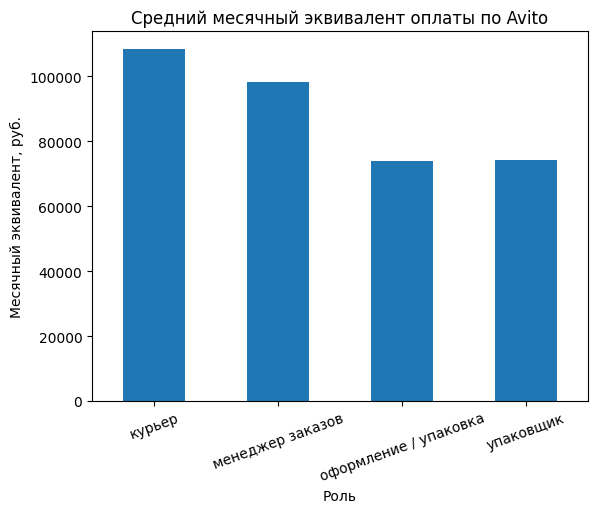

In [21]:
avito_jobs.groupby("position")["salary_monthly_estimated"].mean().round(3).plot(kind="bar")
plt.title("Средний месячный эквивалент оплаты по Avito")
plt.xlabel("Роль")
plt.ylabel("Месячный эквивалент, руб.")
plt.xticks(rotation=20)
plt.show()